# beamboozle_example.ipynb

Author: Thomas Hilder

Date: 14th September, 2026

Requirements: 
- Download the mwc480 cube in the other example folder. 
- `numpy`, `matplotlib`, `discminer`
- Install beamboozle via `pip install git+https://github.com/tomhilder/beam-boozle`

## Short background

Pixels in synthesised interferometric images are not statistically independent. This is ultimately due to the way the data are collected and processed in order to create images. By default, `discminer` does not properly account for these correlations. This is for good reasons: (1) it's not so obvious __how__ the pixels are correlated (2) it's naively computationally expensive to account for correlated pixels in a large image. These are each discussed further below.

Unfortunately, Bayesian inference (which `discminer` performs via Markov Chain Monte Carlo) is contingent on the choice of model, and this includes the __noise model__. By using a likelihood function that assumes independent pixels, the inference incorrectly assumes the data contain far more information they do, and the resultant uncertainties are overconfident.

Binning alleviates this to some level, but it does so by throwing away information. It would be good to be able to just use an accurate noise model and likelihood function, such that we can avoid binning. Beamboozle enables exactly that, without incurring massive cost.

### How are the pixels correlated?

The so-called __dirty__ image is what one obtains by Fourier transforming the visibilities data. Assuming noiseless visibilities for now, the dirty image can be considered to be the __true__ image, convolved with a point-spread function (PSF) that is determined by the configuration of the array. This PSF (the "dirty beam") is weird. Because the sampling of spatial frequencies by the telescope is discrete and incomplete (that is, we obtain no information for many frequencies), the PSF is not a simple ellipse or Gaussian, and has __side-lobes__. What is meant by this, is that the PSF is not compact: each pixel in the dirty image is a mix of information from all over the true image, not a small area of the true image.

CLEAN, and other imaging algorithms, attempt to de-convolve the dirty image by making use of knowledge of the PSF/array configuration. In a strict sense, the convolution with the PSF is not invertible, since information is actually lost. That said, for many of the cases of interest to the protoplanetary disk/`discminer` community, the spatial frequency coverage is good enough that imaging algorithms perform very well.

Roughly speaking, CLEAN takes a guess-and-check approach to imaging in that it builds up a candidate image one piece at a time and compares to the observed image in each step by convolving with the dirty beam. Importantly, this process is only capable of deconvolving the __signal__. Any noise in the data is __not__ deconvolved by this process (the process of removing correlation from noisy data is called whitening: CLEAN does not whiten the data). After the deconvolution process, the CLEAN model image is generally convolved with an idealised Gaussian PSF (the "CLEAN beam") to suppress high-spatial-frequency artefacts. The noise __is__ affected by this.

All this means that the final image(s) have noise that is not distributed according to the dirty beam nor the CLEAN beam. Tsukui+2023 go through this a bit more carefully and advocate for estimating the autocorrelation function (ACF) of the noise empirically from images containing __only__ noise. We will follow suit, except that the computational speed-up `beamboozle` utilises actually requries the power spectral density (PSD) of the noise. Luckily this is also easy to estimate and `beamboozle` will do it for us anyway. This is similar in spirit to a typical move of estimating the per-pixel RMS noise in noise-only images, except including the correlations.

### How do we include the correlations in the inference?

Bayesian inference from a parametric model, as is the case in `discminer`, requires including a likelihood function that describes how the noise is distributed in the data. The default in `discminer` assumes independent Gaussian noise in each pixel via the following (log) likelhood function:
$$
\log \mathcal{L} = - \frac{1}{2} \sum_{i \in \mathrm{pixels}} \frac{(I^\mathrm{data}_i - I^\mathrm{model}_i)^2}{\sigma_i^2} + \mathrm{const}.
$$
This expression is a sum because it arises as the log of the product of many independent probability density functions. Including the correlations between neighbouring pixels, we can no longer make this factorisation and instead must deal with the data __vector__ $\mathbf{I}^\mathrm{data} = [I^\mathrm{data}_1, \dots, I^\mathrm{data}_n]$ and the full __covariance matrix__ $[\mathbf{C}]_{ij} = \rho_{ij} \sigma_i \sigma_j$, where $\rho_{ij}$ gives the correlation between pixels $i$ and $j$. The likelihood is still Gaussian, but the Gaussian distribution is no-longer diagonal/independent between dimensions (of which there are one per-pixel):
$$
\log \mathcal{L} = - \frac{1}{2} (\mathbf{I}^\mathrm{data})^\top \, \mathbf{C}^{-1} \, \mathbf{I}^\mathrm{data},
$$
We can assume we know how to get $\mathbf{C}$ (because of the previous section). So what's the problem? Say each image has $1024$ pixels on each side. $\mathbf{I}^\mathrm{data}$ is then a vector with a million entries, and the covariance matrix is $10^6 \times 10^6$. Evaluating a matrix multiplication of this size is super expensive/slow!

`beamboozle` solves this problem by utilising the fact that the Fourier transform diagonalises stationary noise processes to get back to a factorised structure, but in Fourier space. This is why it needs the PSD of the noice instead of covariance matrix (or ACF, equivalently). More details can be found (or will be able to be found in future) in the `beamboozle` paper.

The entire point of `beamboozle` is to provide a fast, drop-in likelihood function that includes the correlation. That is also __all__ it does. It is useless for analyses that do not use a likelihood.

### Caveats

`beamboozle` does not address the uncertainty contributed by imaging and the finite sampling of the uv-plane. This should be sub-dominant in most cases where `discminer` is being used. It also does not account for the fact that the primary beam changes the noise a bit across the image. This is also a small effect.

The speed-up also assumes implicitly periodic boundary conditions for the image. This causes negligible error provided that the signal part of the image is at least a couple beams away from the edge.

This also still does not account for the spectral covariance. In principle we could use a similar trick to include that, but it is not (yet) included.

Finally, the properties of the noise will not quite be characterised correctly in the regions where the signal is, since CLEAN is local and non-linear. This should also be a small effect. This can be completely mitigated however, by simply fitting to the dirty image. I would strongly advocate that this is actually the best-motivated thing to do (besides fitting visibilities which is difficult and larger change).

## Correlated noise in `discminer`

In principle, compared to a typical workflow, there are only two steps:

```python
from discminer.noise import estimate_inv_psd

inv_psd = estimate_inv_psd(datacube, channels=line_free_channels)
model.run_mcmc(data, vchannels, ..., noise_psd_inv=inv_psd)
```

`estimate_inv_psd` measures the noise correlation structure empirically from line-free channels
and hands `run_mcmc` an inverse power spectral density. 

The likelihood evaluations are done with
FFTs by `beamboozle` (https://github.com/TomHilder/beam-boozle), so it costs
`O(N log N)` per channel and never builds a covariance matrix.

### Step 1: Estimate the noise

In [1]:
from discminer.core import Data
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from astropy import units as u

# Point at a cube
DATA_FILE = Path("../mwc480_12co/MWC_480_CO_220GHz.robust_0.5.JvMcorr.image.pbcor.fits")
DATA_FILE.is_file()

DPC = 162.0 * u.pc  # Distance to system
NPIX = 300  # Number of pixels for cutout
SNR_LINE = 5.0  # Include channels whose peak SNR is below this value

# Read the cube
datacube = Data(DATA_FILE, DPC)
print(f"cube shape = {datacube.data.shape}")

/Users/tomhilder/Documents/PhD/research/fast_corr_likelihoods/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cube shape = (133, 2048, 2048)


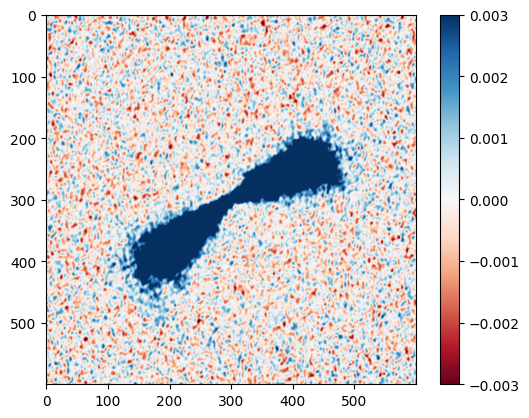

In [2]:
# Truncate the channels to the central region of interest
ny, nx = datacube.data.shape[1:]
win = np.s_[:, ny // 2 - NPIX : ny // 2 + NPIX, nx // 2 - NPIX : nx // 2 + NPIX]
central = datacube.data[win]

# Plot a channel to check we didn't clip too much
plt.figure()
plt.imshow(central[65], cmap="RdBu", vmin=-3e-3, vmax=3e-3)
plt.colorbar()
plt.show()

In [3]:
# Noise level using median absolute deviation (robust against signal contribution)
rms = 1.4826 * np.nanmedian(np.abs(central - np.nanmedian(central)))
print(f"rms = {rms:.6f}")
peak_snr = np.nanmax(central, axis=(1, 2)) / rms
line_free = np.flatnonzero(peak_snr < SNR_LINE)
print(f"number of noise-only channels = {len(line_free)}")

datacube.clip(
    npix=NPIX,
    channels={"indices": list(line_free)},
)

rms = 0.000799
number of noise-only channels = 18
Clipping datacube...


/Users/tomhilder/Documents/PhD/research/fast_corr_likelihoods/subprojects/discminer/discminer/cube.py:243: Warning: If the selected channels are not regularly spaced, the header of the output FITS file will not reflect this. External analysis tools such as CASA or DS9 may not display the velocity information correctly.
  warnings.warn("If the selected channels are not regularly spaced, the header of the output FITS file will not reflect this. External analysis tools such as CASA or DS9 may not display the velocity information correctly.", Warning)


As a quick demo, we'll make a plot that shows the amount of correlation between nearby pixels in the noise.

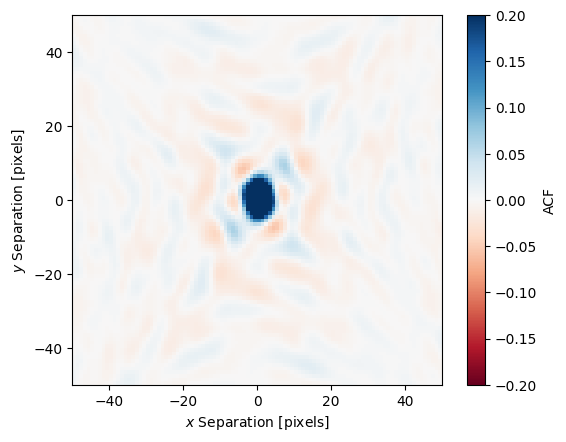

In [4]:
from beam_boozle.utils import estimate_noise_acf_masked

# Get the autocorrelation function empirically
acf, variance = estimate_noise_acf_masked(datacube.data)
# Put zero separation at centre (default ordering is different)
acf = np.fft.fftshift(acf / variance)

acf_pix = 50
plt.figure()
plt.imshow(
    acf[NPIX - acf_pix : NPIX + acf_pix, NPIX - acf_pix : NPIX + acf_pix],
    cmap="RdBu",
    vmin=-0.2,
    vmax=0.2,
    extent=[-acf_pix, acf_pix, -acf_pix, acf_pix],
    origin="lower",
)
plt.xlabel("$x$ Separation [pixels]")
plt.ylabel("$y$ Separation [pixels]")
plt.colorbar(label="ACF")
plt.show()

Now, we'll actually estimate the thing we require, which is the inverse PSD of the noise. And we'll plot it.

/Users/tomhilder/Documents/PhD/research/fast_corr_likelihoods/subprojects/discminer/discminer/noise.py:168: UserWarning: Estimating the noise PSD from only 10 channels biases the inverse PSD high, making posteriors somewhat overconfident. 20 or more line-free channels are recommended.
  warnings.warn(


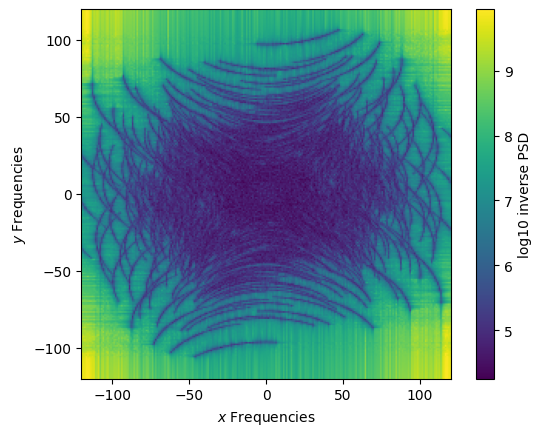

In [5]:
from discminer.noise import estimate_inv_psd

# This is all you actually need
inv_psd = estimate_inv_psd(
    datacube,
    white_floor=1e-4,
    smooth=None,
)

psd_pix = 120
plt.figure()
plt.imshow(
    np.fft.fftshift(np.log10(inv_psd))[
        NPIX - psd_pix : NPIX + psd_pix, NPIX - psd_pix : NPIX + psd_pix
    ],
    cmap="viridis",
    extent=[-psd_pix, psd_pix, -psd_pix, psd_pix],
    origin="lower",
)
plt.xlabel("$x$ Frequencies")
plt.ylabel("$y$ Frequencies")
plt.colorbar(label="log10 inverse PSD")
plt.show()

Pretty weird no? The strange shape is the uv-sampling of the array configuration showing up.

### Step 2: Use correlated likelihoods in discminer

This step is very simple. The typical workflow should be followed, except that when running the MCMC one should call

```python
model.run_mcmc(data, vchannels, p0_mean=p0, nwalkers=32, nsteps=4000,
               noise_psd_inv=inv_psd)          # instead of noise_stddev=rms
```

Using the noise_psd_inv argument, and supplying it with `inv_psd` as measured above, is all that is needed. Do not pass `noise_stddev` in this case.